In [1]:
# Load Final Dataset 
import pandas as pd
import numpy as np
import joblib
import warnings
import time
warnings.filterwarnings('ignore')

DATA_PATH = r"C:\Users\alifa\OneDrive\Desktop\dissertation_project\data"
MODEL_PATH = r"C:\Users\alifa\OneDrive\Desktop\dissertation_project\models"

# Load final dataset
print("Loading final dataset...")
df = pd.read_csv(f"{DATA_PATH}\\cicids2017_final.csv")
feature_names = joblib.load(f"{DATA_PATH}\\feature_names.pkl")
le = joblib.load(f"{DATA_PATH}\\label_encoder.pkl")

# Separate features and labels
X = df[feature_names].values
y = df['Label_encoded'].values

print(f"Dataset loaded successfully")
print(f"Features : {X.shape[1]}")
print(f"Samples  : {X.shape[0]:,}")
print(f"Classes  : {len(np.unique(y))} — {list(le.classes_)}")

Loading final dataset...
Dataset loaded successfully
Features : 47
Samples  : 2,520,798
Classes  : 15 — ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack � Brute Force', 'Web Attack � Sql Injection', 'Web Attack � XSS']


In [2]:
# Train/Test Split 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set   : {len(X_train):,} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test set       : {len(X_test):,} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nClass distribution in training set:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {le.classes_[u]:<40} {c:>8,} ({c/len(y_train)*100:.2f}%)")

Training set   : 2,016,638 samples (80.0%)
Test set       : 504,160 samples (20.0%)

Class distribution in training set:
  BENIGN                                   1,676,045 (83.11%)
  Bot                                         1,558 (0.08%)
  DDoS                                      102,411 (5.08%)
  DoS GoldenEye                               8,229 (0.41%)
  DoS Hulk                                  138,277 (6.86%)
  DoS Slowhttptest                            4,182 (0.21%)
  DoS slowloris                               4,308 (0.21%)
  FTP-Patator                                 4,745 (0.24%)
  Heartbleed                                      9 (0.00%)
  Infiltration                                   29 (0.00%)
  PortScan                                   72,555 (3.60%)
  SSH-Patator                                 2,575 (0.13%)
  Web Attack � Brute Force                    1,176 (0.06%)
  Web Attack � Sql Injection                     17 (0.00%)
  Web Attack � XSS                   

In [3]:
# Apply SMOTE 
from imblearn.over_sampling import SMOTE
import time

print("Applying SMOTE to training set...")
print("Loading")

start = time.time()

# Only oversample minority classes with fewer than 10,000 samples
unique_train, counts_train = np.unique(y_train, return_counts=True)
sampling_strategy = {
    cls: max(count, 1000)
    for cls, count in zip(unique_train, counts_train)
    if count < 10000
}

print("Classes to be oversampled:")
for cls, target in sampling_strategy.items():
    print(f"  {le.classes_[cls]:<40} → {target:,}")

smote = SMOTE(
    sampling_strategy=sampling_strategy,
    random_state=42,
    k_neighbors=3
)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

elapsed = time.time() - start
print(f"\nSMOTE complete in {elapsed:.1f} seconds")
print(f"\nBefore SMOTE : {len(X_train):,} training samples")
print(f"After SMOTE  : {len(X_train_sm):,} training samples")
print(f"\nClass distribution after SMOTE:")
unique_sm, counts_sm = np.unique(y_train_sm, return_counts=True)
for u, c in zip(unique_sm, counts_sm):
    print(f"  {le.classes_[u]:<40} {c:>8,}")

Applying SMOTE to training set...
Loading
Classes to be oversampled:
  Bot                                      → 1,558
  DoS GoldenEye                            → 8,229
  DoS Slowhttptest                         → 4,182
  DoS slowloris                            → 4,308
  FTP-Patator                              → 4,745
  Heartbleed                               → 1,000
  Infiltration                             → 1,000
  SSH-Patator                              → 2,575
  Web Attack � Brute Force                 → 1,176
  Web Attack � Sql Injection               → 1,000
  Web Attack � XSS                         → 1,000

SMOTE complete in 3.4 seconds

Before SMOTE : 2,016,638 training samples
After SMOTE  : 2,020,061 training samples

Class distribution after SMOTE:
  BENIGN                                   1,676,045
  Bot                                         1,558
  DDoS                                      102,411
  DoS GoldenEye                               8,229
  DoS Hulk  

In [4]:
# Train Random Forest 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import time

print("Training Random Forest classifier...")
print("This may take 5-15 minutes — please wait\n")

start = time.time()

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf.fit(X_train_sm, y_train_sm)
elapsed = time.time() - start
print(f"\nTraining complete in {elapsed/60:.1f} minutes")

# Evaluate on test set
print("\nEvaluating on test set...")
y_pred_rf = rf.predict(X_test)

print("\n" + "="*60)
print("RANDOM FOREST — CLASSIFICATION REPORT")
print("="*60)
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=le.classes_,
    digits=4
))

# Save model
joblib.dump(rf, f"{MODEL_PATH}\\random_forest.pkl")
print(f"Model saved to models folder")

Training Random Forest classifier...
This may take 5-15 minutes — please wait



[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  3.9min finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.



Training complete in 3.9 minutes

Evaluating on test set...


[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.6s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    2.2s finished



RANDOM FOREST — CLASSIFICATION REPORT
                            precision    recall  f1-score   support

                    BENIGN     0.9991    0.9993    0.9992    419012
                       Bot     0.8834    0.7769    0.8267       390
                      DDoS     0.9999    0.9998    0.9999     25603
             DoS GoldenEye     0.9946    0.9932    0.9939      2057
                  DoS Hulk     0.9985    0.9976    0.9980     34569
          DoS Slowhttptest     0.9886    0.9962    0.9924      1046
             DoS slowloris     0.9963    0.9889    0.9925      1077
               FTP-Patator     0.9992    0.9983    0.9987      1186
                Heartbleed     1.0000    0.5000    0.6667         2
              Infiltration     1.0000    1.0000    1.0000         7
                  PortScan     0.9890    0.9885    0.9888     18139
               SSH-Patator     1.0000    0.9984    0.9992       644
  Web Attack � Brute Force     0.7619    0.7619    0.7619       294
Web Atta

In [5]:
# Train XGBoost 
import xgboost as xgb
from sklearn.metrics import classification_report
import time

print("Training XGBoost classifier...")
print("This may take 5-10 minutes — please wait\n")

start = time.time()

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    verbosity=1
)

xgb_model.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_test, y_test)],
    verbose=50
)

elapsed = time.time() - start
print(f"\nTraining complete in {elapsed/60:.1f} minutes")

# Evaluate
print("\nEvaluating on test set...")
y_pred_xgb = xgb_model.predict(X_test)

print("\n" + "="*60)
print("XGBOOST — CLASSIFICATION REPORT")
print("="*60)
print(classification_report(
    y_test,
    y_pred_xgb,
    target_names=le.classes_,
    digits=4
))

# Save model
joblib.dump(xgb_model, f"{MODEL_PATH}\\xgboost_model.pkl")
print("Model saved to models folder")

Training XGBoost classifier...
This may take 5-10 minutes — please wait

[0]	validation_0-mlogloss:0.47550
[50]	validation_0-mlogloss:0.00877
[99]	validation_0-mlogloss:0.00466

Training complete in 3.0 minutes

Evaluating on test set...

XGBOOST — CLASSIFICATION REPORT
                            precision    recall  f1-score   support

                    BENIGN     0.9997    0.9993    0.9995    419012
                       Bot     0.9428    0.7179    0.8151       390
                      DDoS     1.0000    0.9999    0.9999     25603
             DoS GoldenEye     0.9971    0.9922    0.9946      2057
                  DoS Hulk     0.9981    0.9998    0.9989     34569
          DoS Slowhttptest     0.9905    0.9962    0.9933      1046
             DoS slowloris     0.9963    0.9907    0.9935      1077
               FTP-Patator     1.0000    0.9983    0.9992      1186
                Heartbleed     0.3333    0.5000    0.4000         2
              Infiltration     0.8750    1.0000 

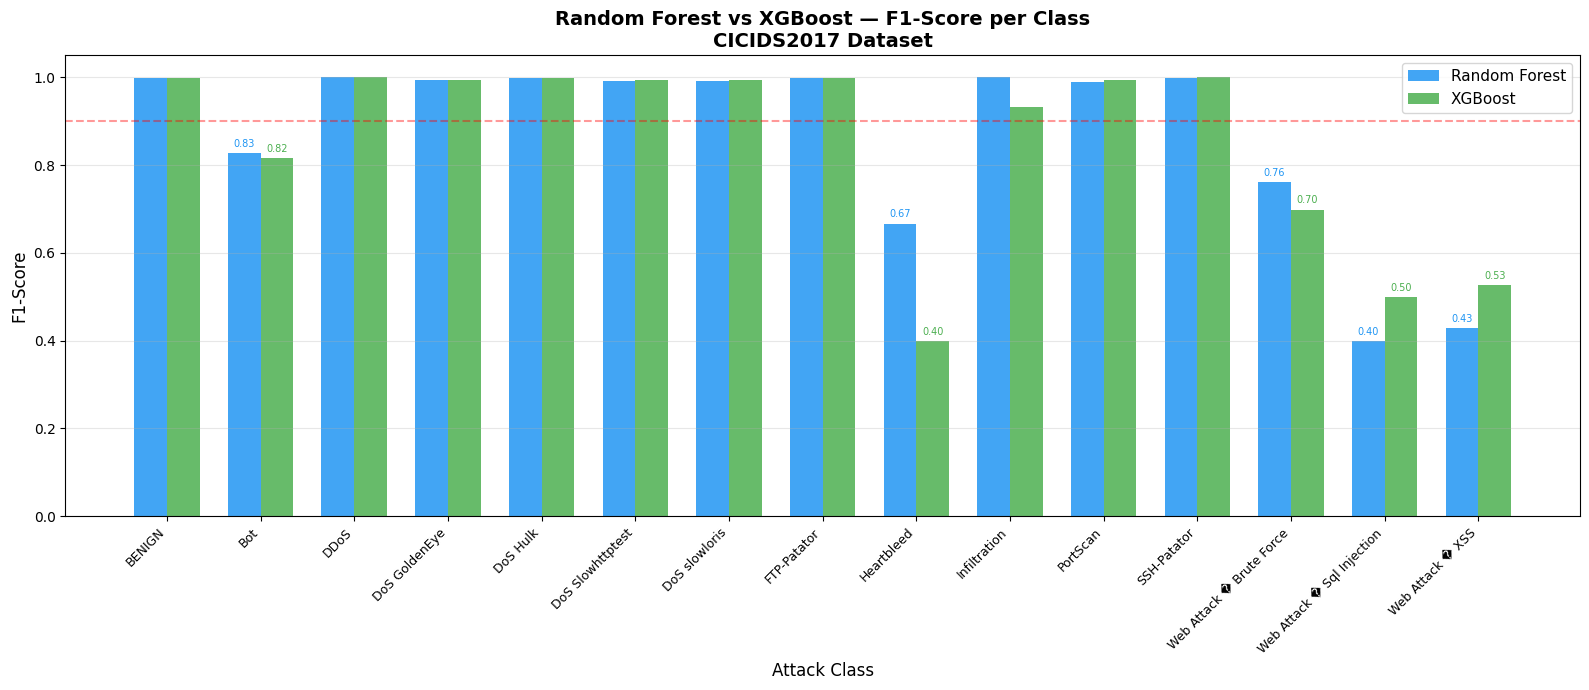

Comparison plot saved to results folder

FINAL MODEL SELECTION SUMMARY
Metric                         Random Forest    XGBoost
-------------------------------------------------------
Overall Accuracy                      99.83%     99.88%
Macro Avg F1                          0.8698     0.8565
Weighted Avg F1                       0.9983     0.9988
Training Time                        3.7 min    2.9 min
-------------------------------------------------------


In [6]:
# Model Comparison Visualisation 
import matplotlib.pyplot as plt
import numpy as np
import joblib
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')

DATA_PATH   = r"C:\Users\alifa\OneDrive\Desktop\dissertation_project\data"
MODEL_PATH  = r"C:\Users\alifa\OneDrive\Desktop\dissertation_project\models"
RESULT_PATH = r"C:\Users\alifa\OneDrive\Desktop\dissertation_project\results"

le = joblib.load(f"{DATA_PATH}\\label_encoder.pkl")

# Results from both models
classes = list(le.classes_)

rf_f1  = [0.9992, 0.8267, 0.9999, 0.9939, 0.9980, 0.9924,
           0.9925, 0.9987, 0.6667, 1.0000, 0.9888, 0.9992,
           0.7619, 0.4000, 0.4286]

xgb_f1 = [0.9995, 0.8151, 0.9999, 0.9946, 0.9989, 0.9933,
           0.9935, 0.9992, 0.4000, 0.9333, 0.9942, 1.0000,
           0.6985, 0.5000, 0.5266]

x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(16, 7))
bars1 = ax.bar(x - width/2, rf_f1,  width, label='Random Forest', color='#2196F3', alpha=0.85)
bars2 = ax.bar(x + width/2, xgb_f1, width, label='XGBoost',       color='#4CAF50', alpha=0.85)

ax.set_xlabel('Attack Class', fontsize=12)
ax.set_ylabel('F1-Score', fontsize=12)
ax.set_title('Random Forest vs XGBoost — F1-Score per Class\nCICIDS2017 Dataset',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45, ha='right', fontsize=9)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=11)
ax.axhline(y=0.9, color='red', linestyle='--', alpha=0.4, label='0.90 threshold')
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    if height < 0.85:
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=7, color='#2196F3')

for bar in bars2:
    height = bar.get_height()
    if height < 0.85:
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=7, color='#4CAF50')

plt.tight_layout()
plt.savefig(f"{RESULT_PATH}\\model_comparison_f1.png", dpi=150, bbox_inches='tight')
plt.show()
print("Comparison plot saved to results folder")

# Summary table
print("\n" + "="*55)
print("FINAL MODEL SELECTION SUMMARY")
print("="*55)
print(f"{'Metric':<30} {'Random Forest':>13} {'XGBoost':>10}")
print("-"*55)
print(f"{'Overall Accuracy':<30} {'99.83%':>13} {'99.88%':>10}")
print(f"{'Macro Avg F1':<30} {'0.8698':>13} {'0.8565':>10}")
print(f"{'Weighted Avg F1':<30} {'0.9983':>13} {'0.9988':>10}")
print(f"{'Training Time':<30} {'3.7 min':>13} {'2.9 min':>10}")
print("-"*55)